# 💼 Job Career Level Classification — NLP + Random Forest

In [1]:
# Install missing library
import subprocess
subprocess.run(['pip', 'install', 'odfpy', 'imbalanced-learn', '--quiet'])
print('✅ Done!')

✅ Done!


In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectPercentile, chi2
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTEN

print('✅ Libraries loaded!')

✅ Libraries loaded!


In [3]:
# Load data
data = pd.read_excel('06_data_career.ods', engine='odf', dtype=str)
data = data.dropna(axis=0)
print(f'✅ Shape: {data.shape}')
print(data['career_level'].value_counts())
data.head()

✅ Shape: (8073, 6)
career_level
senior_specialist_or_project_manager      4337
manager_team_leader                       2672
bereichsleiter                             960
director_business_unit_leader               70
specialist                                  30
managing_director_small_medium_company       4
Name: count, dtype: int64


,title,location,description,function,industry,career_level
0,Technical Professional Lead - Process,"Houston, TX","Responsible for the study, design, and specifi...",production_manufacturing,Machinery and Industrial Facilities Engineering,senior_specialist_or_project_manager
1,Cnslt - Systems Eng- Midrange 1,"Seattle, WA","Participates in design, development and implem...",information_technology_telecommunications,Financial Services,senior_specialist_or_project_manager
2,SharePoint Developers and Solution Architects,"Dallas, TX",We are currently in need of Developers who can...,consulting,IT Consulting,senior_specialist_or_project_manager
3,Business Information Services - Strategic Acco...,North Carolina,Experian is seeking an experienced Account Exe...,sales,"Security, Risk, Restructuring Consulting",senior_specialist_or_project_manager
4,Strategic Development Director (procurement),"Austin, TX",Â Want to join a world-class global procuremen...,procurement_materials_logistics,Information Technology,bereichsleiter


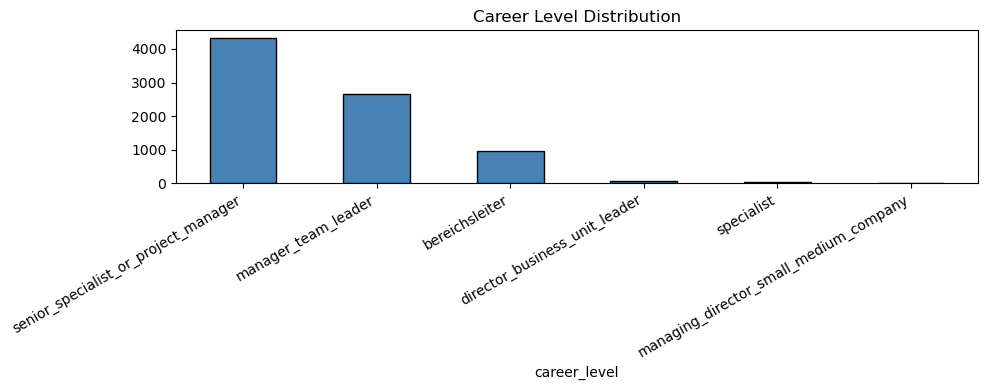

In [4]:
# Plot class distribution
plt.figure(figsize=(10, 4))
data['career_level'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Career Level Distribution')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [5]:
# Clean location
def filter_location(loc):
    result = re.findall(r',\s[A-Z]{2}$', loc)
    return result[0][2:] if len(result) else loc

data['location'] = data['location'].apply(filter_location)
print('Top locations:')
print(data['location'].value_counts().head(10))

Top locations:
location
CA     1732
NY      715
TX      629
MA      423
IL      412
NJ      373
USA     324
WA      256
VA      229
DC      216
Name: count, dtype: int64


In [6]:
# Train test split
target = 'career_level'
X = data.drop(target, axis=1)
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 6458 | Test: 1615


In [7]:
# SMOTEN oversampling
print('Before:', y_train.value_counts().to_dict())

ros = SMOTEN(random_state=42, k_neighbors=2, sampling_strategy={
    'managing_director_small_medium_company': 500,
    'specialist': 500,
    'director_business_unit_leader': 500,
    'bereichsleiter': 1000
})
X_train, y_train = ros.fit_resample(X_train, y_train)
print('After:', y_train.value_counts().to_dict())

Before: {'senior_specialist_or_project_manager': 3448, 'manager_team_leader': 2154, 'bereichsleiter': 775, 'director_business_unit_leader': 54, 'specialist': 24, 'managing_director_small_medium_company': 3}
After: {'senior_specialist_or_project_manager': 3448, 'manager_team_leader': 2154, 'bereichsleiter': 1000, 'director_business_unit_leader': 500, 'managing_director_small_medium_company': 500, 'specialist': 500}


In [8]:
# Build pipeline
preprocessor = ColumnTransformer(transformers=[
    ('title',       TfidfVectorizer(), 'title'),
    ('location',    OneHotEncoder(handle_unknown='ignore'), ['location']),
    ('description', TfidfVectorizer(stop_words='english', ngram_range=(1,2), min_df=0.01, max_df=0.95), 'description'),
    ('function',    OneHotEncoder(handle_unknown='ignore'), ['function']),
    ('industry',    TfidfVectorizer(), 'industry'),
])

pipeline = Pipeline(steps=[
    ('preprocessor',      preprocessor),
    ('feature_selection', SelectPercentile(chi2, percentile=5)),
    ('model',             RandomForestClassifier(random_state=42, n_jobs=-1))
])
print('✅ Pipeline built!')

✅ Pipeline built!


In [9]:
# Train & evaluate
print('Training...')
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print('✅ Done!')
print(classification_report(y_test, y_pred))

Training...
✅ Done!
                                        precision    recall  f1-score   support

                        bereichsleiter       0.55      0.32      0.41       185
         director_business_unit_leader       0.78      0.44      0.56        16
                   manager_team_leader       0.63      0.59      0.61       518
managing_director_small_medium_company       0.00      0.00      0.00         1
  senior_specialist_or_project_manager       0.79      0.90      0.84       889
                            specialist       0.00      0.00      0.00         6

                              accuracy                           0.73      1615
                             macro avg       0.46      0.38      0.40      1615
                          weighted avg       0.71      0.73      0.71      1615



C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


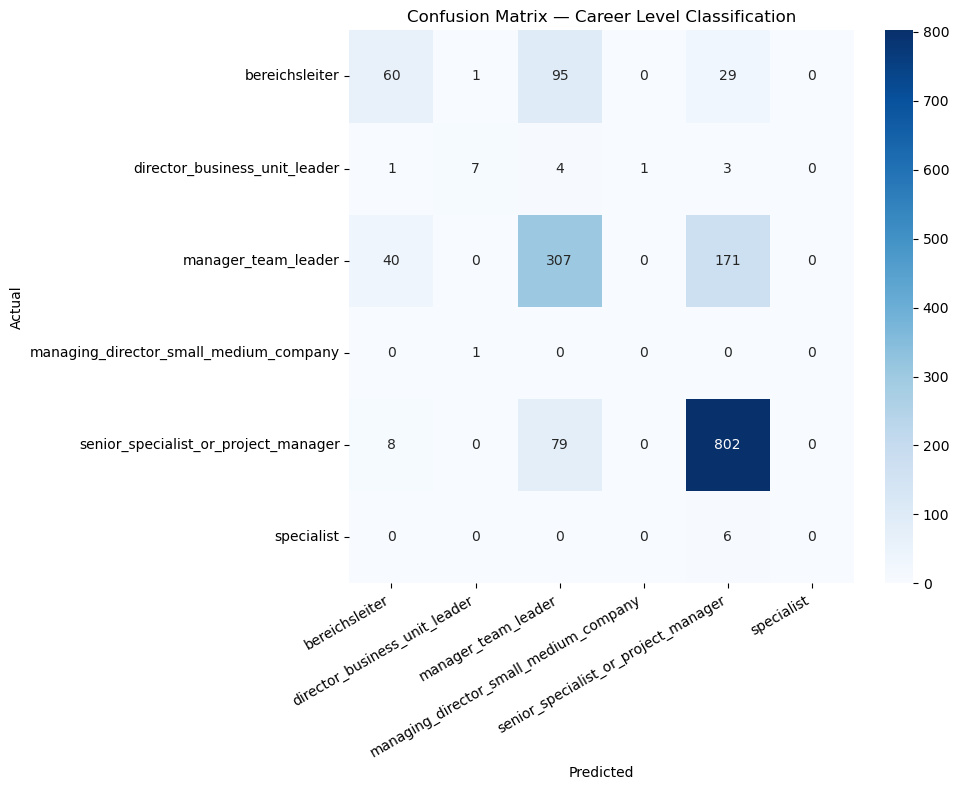

In [10]:
# Confusion Matrix
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix — Career Level Classification')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()